In [10]:
from pathlib import Path
from tqdm.auto import tqdm
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

ROOT = Path(
    "/home/clement/Documents/Projets/OcularRigidity/notebooks/sensitivity/one_cycle"
)
videos = list(ROOT.glob("*Rigidity*"))


In [7]:
results = {}
for video in tqdm(videos):
    output_file = ROOT / "delta_ct_results" / f"{video.name}.pkl"
    if output_file.exists():
        with open(output_file, "rb") as f:
            results[video.name] = pickle.load(f)

  0%|          | 0/229 [00:00<?, ?it/s]

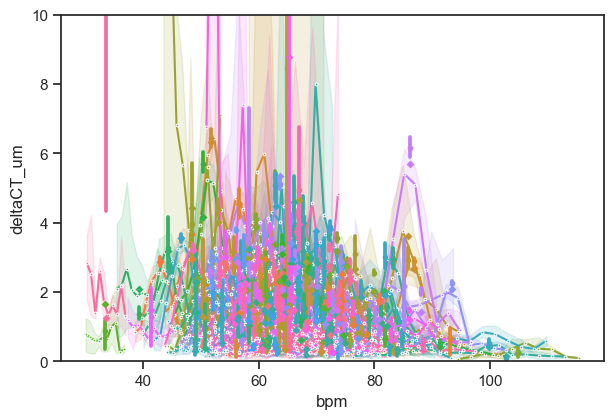

In [31]:
def draw_results(results):
    all_df = []
    for video, cycles in results.items():
        rows = []
        min_bpm = float("inf")
        for k, v in cycles.items():
            if "bpm" not in k:
                continue
            bpm = float(k.split("bpm_")[1].split(".mp4")[0])
            min_bpm = min(min_bpm, bpm)
            for cycle_idx, delta_ct in enumerate(v):
                rows.append(
                    {
                        "bpm": bpm,
                        "deltaCT_um": delta_ct.deltaCT_um,
                        "Cycle": cycle_idx,
                        "Video": video,
                        "cat": "imposed_bpm",
                    }
                )
        id_demod = cycles["ls_iq_demod.mp4"]
        for cycle_idx, delta_ct in enumerate(id_demod):
            rows.append(
                {
                    "bpm": min_bpm / 0.9,
                    "deltaCT_um": delta_ct.deltaCT_um,
                    "Cycle": cycle_idx,
                    "Video": video,
                    "cat": "id_demod",
                }
            )

        id_demod = cycles["ls_linear.mp4"]
        for cycle_idx, delta_ct in enumerate(id_demod):
            rows.append(
                {
                    "bpm": min_bpm / 0.9,
                    "deltaCT_um": delta_ct.deltaCT_um,
                    "Cycle": cycle_idx,
                    "Video": video,
                    "cat": "linear_phase",
                }
            )

        df = pd.DataFrame(rows)
        all_df.append(df)
    df = pd.concat(all_df, ignore_index=True)
    return df


# Only plot the results where iq_demod was the maximum deltaCT, to avoid cluttering the plot with videos that are not pulsatile.

df = draw_results(results)
# df = df[~df.confirmed_bpm]
# df = df[df.Video.isin(df.Video.unique()[:50])]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax = sns.lineplot(
    data=df[df.cat == "imposed_bpm"],
    x="bpm",
    y="deltaCT_um",
    hue="Video",
    # palette=palette,
    errorbar=("pi", 95),
    marker="o",
    markersize=2,
    ax=ax,
    legend=None,
    # Set opacity of the error bars to 0.5
    err_kws={"alpha": 0.15},
)
ax = sns.pointplot(
    data=df[df.cat == "id_demod"],
    x="bpm",
    y="deltaCT_um",
    hue="Video",
    native_scale=True,  # <- keeps x numeric instead of categorical
    errorbar=("pi", 95),
    ax=ax,
    legend=False,
    markersize=2,
)

ax = sns.pointplot(
    data=df[df.cat == "linear_phase"],
    x="bpm",
    y="deltaCT_um",
    hue="Video",
    native_scale=True,
    ax=ax,
    legend=False,
    marker="D",
    markersize=2,
    linestyle="none",
    errorbar=None,
)
plt.ylim(0, 10)
plt.show()


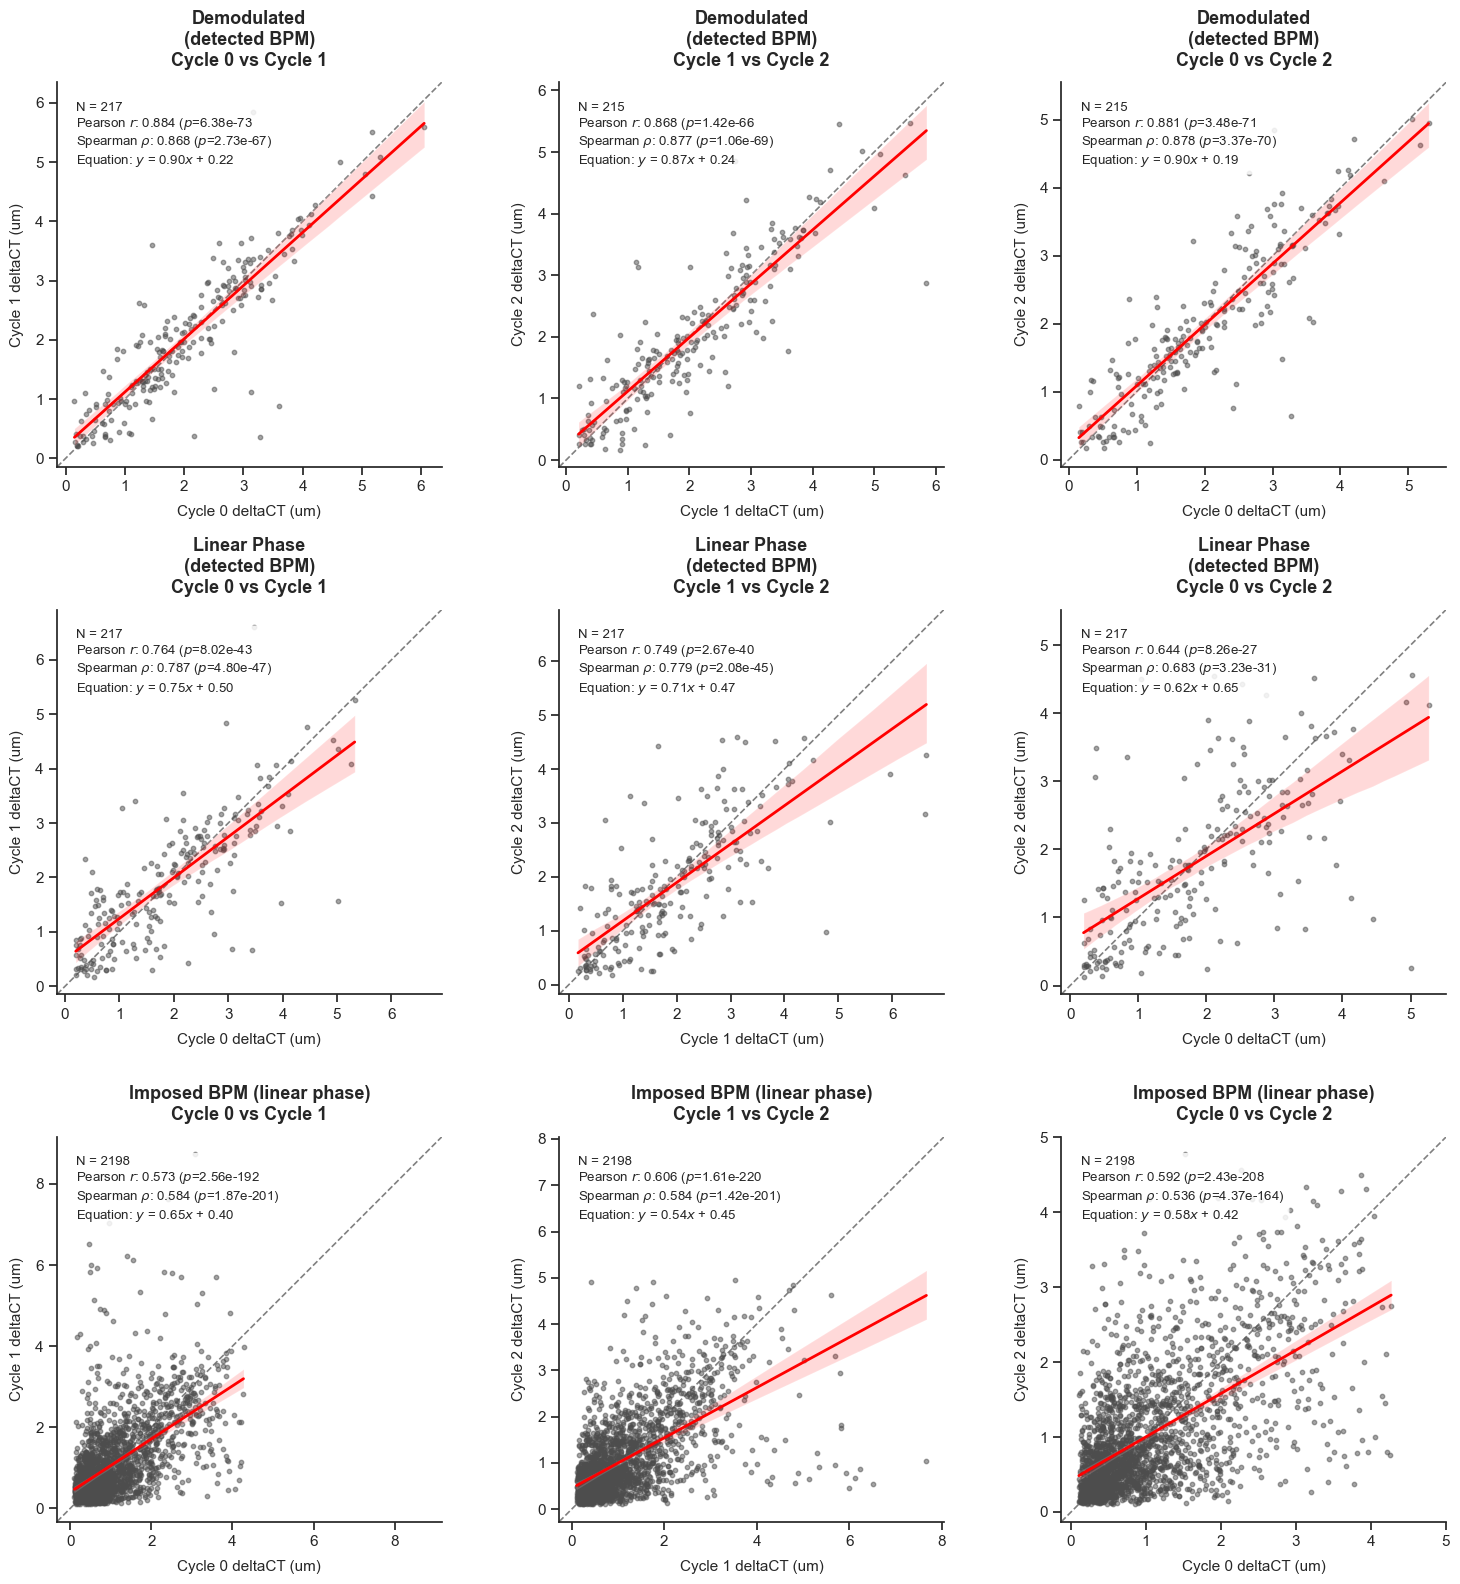

In [36]:
# | label: fig-sensitivity-analysis-hr-replicability
# | echo: false
# | warning: false
# | fig-cap: "Replicability comparison. First row: estimating the deltaCT from the demodulated signal, second row: estimating the deltaCT from the linear phase signal at the same BPM, third row: estimating the deltaCT from the imposed bpm. Each column corresponds to a different cycle comparison."

from ocularrigidity.stats.plot import regression_plot_with_stats


fig, axes = plt.subplots(3, 3, figsize=(16, 16))
for i, (label, category) in enumerate(
    zip(
        [
            "Demodulated\n(detected BPM)",
            "Linear Phase\n(detected BPM)",
            "Imposed BPM (linear phase)",
        ],
        ["id_demod", "linear_phase", "imposed_bpm"],
    )
):
    for j, cycle in enumerate([(0, 1), (1, 2), (0, 2)]):
        cycle_a, cycle_b = cycle
        col_a, col_b = f"cycle_{cycle_a}", f"cycle_{cycle_b}"
        df_cycle = df[df.cat == category]
        df_cycle = df_cycle[df_cycle.Cycle.isin([cycle_a, cycle_b])]
        df_cycle = (
            df_cycle.pivot_table(
                index=["Video", "bpm"], columns="Cycle", values="deltaCT_um"
            )
            .rename(columns=lambda c: f"cycle_{c}")
            .reset_index()
        )
        ax = axes[i, j]
        regression_plot_with_stats(
            df_cycle,
            x=col_a,
            y=col_b,
            ax=ax,
            title=f"{label}\nCycle {cycle_a} vs Cycle {cycle_b}",
            xlabel=f"Cycle {cycle_a} deltaCT (um)",
            ylabel=f"Cycle {cycle_b} deltaCT (um)",
            print_stats=False,
            drop_outlier_quantile=0.99,
        )

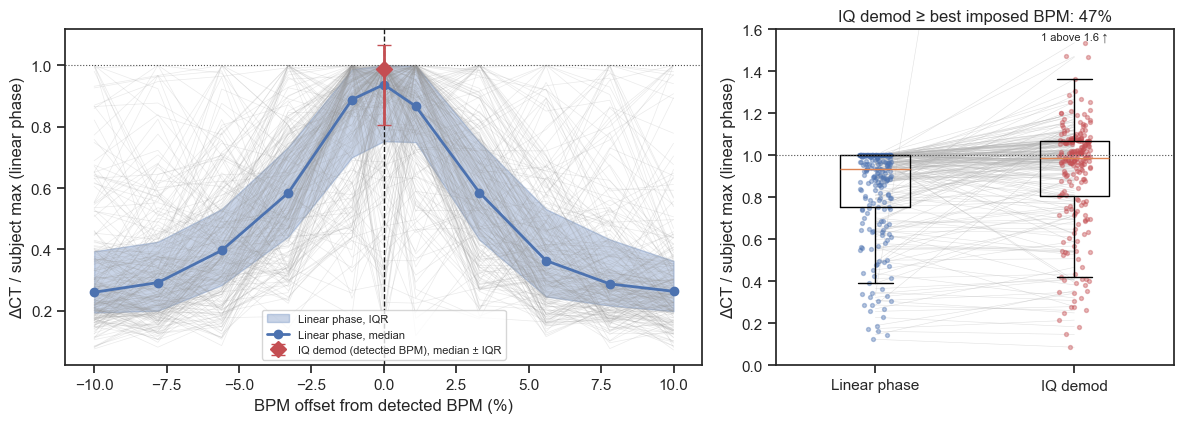

In [ ]:
# | label: fig-sensitivity-analysis-hr-peaks
# | echo: false
# | warning: false
# | fig-cap: "Peak analysis of the sensitivity curves. Left: sensitivity curve for each video, with the median and interquartile range across videos. Right: paired comparison of the linear phase and demodulated deltaCT at the detected BPM."
def sensitivity_df(results):
    def med(v):  # median over cycles
        return np.median([d.deltaCT_um for d in v])

    rows = []
    for video, cycles in results.items():
        grid = {
            float(k.split("bpm_")[1].removesuffix(".mp4")): v
            for k, v in cycles.items()
            if "bpm_" in k
        }
        bpm_est = (min(grid) + max(grid)) / 2
        for bpm, v in grid.items():
            rows.append(
                {
                    "Video": video,
                    "cat": "imposed_bpm",
                    "offset_pct": round(100 * (bpm / bpm_est - 1), 1),
                    "deltaCT_um": med(v),
                }
            )
        rows.append(
            {
                "Video": video,
                "cat": "linear_phase",
                "offset_pct": 0.0,
                "deltaCT_um": med(cycles["ls_linear.mp4"]),
            }
        )
        rows.append(
            {
                "Video": video,
                "cat": "id_demod",
                "offset_pct": 0.0,
                "deltaCT_um": med(cycles["ls_iq_demod.mp4"]),
            }
        )
    sens = pd.DataFrame(rows)
    # Normalize by the best linear-phase value (imposed grid + detected BPM)
    ref = sens[sens.cat != "id_demod"].groupby("Video").deltaCT_um.max()
    sens["norm"] = sens.deltaCT_um / sens.Video.map(ref)
    return sens


def fit_peak(g):
    a, b, _ = np.polyfit(g.offset_pct, g.norm, 2)
    return pd.Series(
        {
            "curvature": a,
            "vertex": -b / (2 * a) if a < 0 else np.nan,
            "argmax": g.offset_pct.iloc[g.norm.argmax()],
        }
    )


sens = sensitivity_df(results)
curve = sens[sens.cat != "id_demod"]
demod = sens[sens.cat == "id_demod"].set_index("Video").norm
lin = sens[sens.cat == "linear_phase"].set_index("Video").norm.loc[demod.index]
peaks = curve.groupby("Video")[["offset_pct", "norm"]].apply(fit_peak)

fig, (ax0, ax1) = plt.subplots(
    1, 2, figsize=(12, 4.4), gridspec_kw={"width_ratios": [1.6, 1]}
)

# Left: sensitivity curve + IQ demod at the detected BPM
for _, g in curve.sort_values("offset_pct").groupby("Video"):
    ax0.plot(g.offset_pct, g.norm, color="0.6", lw=0.5, alpha=0.2)
q = curve.groupby("offset_pct").norm.quantile([0.25, 0.5, 0.75]).unstack()
ax0.fill_between(
    q.index, q[0.25], q[0.75], color="C0", alpha=0.3, label="Linear phase, IQR"
)
ax0.plot(q.index, q[0.5], "o-", color="C0", lw=2, label="Linear phase, median")
dq = demod.quantile([0.25, 0.5, 0.75])
ax0.errorbar(
    0,
    dq[0.5],
    yerr=[[dq[0.5] - dq[0.25]], [dq[0.75] - dq[0.5]]],
    fmt="D",
    color="C3",
    ms=8,
    capsize=5,
    lw=2,
    zorder=5,
    label="IQ demod (detected BPM), median ± IQR",
)
ax0.axvline(0, color="k", ls="--", lw=1)
ax0.axhline(1, color="0.3", lw=0.8, ls=":")
ax0.set(
    xlabel="BPM offset from detected BPM (%)", ylabel="ΔCT / subject max (linear phase)"
)
ax0.legend(loc="lower center", fontsize=8)

# Right: paired linear phase vs IQ demod at the detected BPM
rng = np.random.default_rng(0)
jit = rng.uniform(-0.08, 0.08, (2, len(demod)))
for v in demod.index:
    ax1.plot([0, 1], [lin[v], demod[v]], color="0.7", lw=0.4, alpha=0.4, zorder=-1)
ax1.scatter(jit[0], lin, s=8, color="C0", alpha=0.4)
ax1.scatter(1 + jit[1], demod, s=8, color="C3", alpha=0.4)
ax1.boxplot([lin, demod], positions=[0, 1], widths=0.35, showfliers=False)
ax1.axhline(1, color="0.3", lw=0.8, ls=":")
ymax = 1.6
ax1.set_ylim(0, ymax)
if n_out := (demod > ymax).sum():
    ax1.text(1, ymax - 0.05, f"{n_out} above {ymax} ↑", ha="center", fontsize=8)
ax1.set_xticks([0, 1], ["Linear phase", "IQ demod"])
ax1.set(
    ylabel="ΔCT / subject max (linear phase)",
    title=f"IQ demod ≥ best imposed BPM: {(demod >= 1).mean():.0%}",
)
fig.tight_layout()


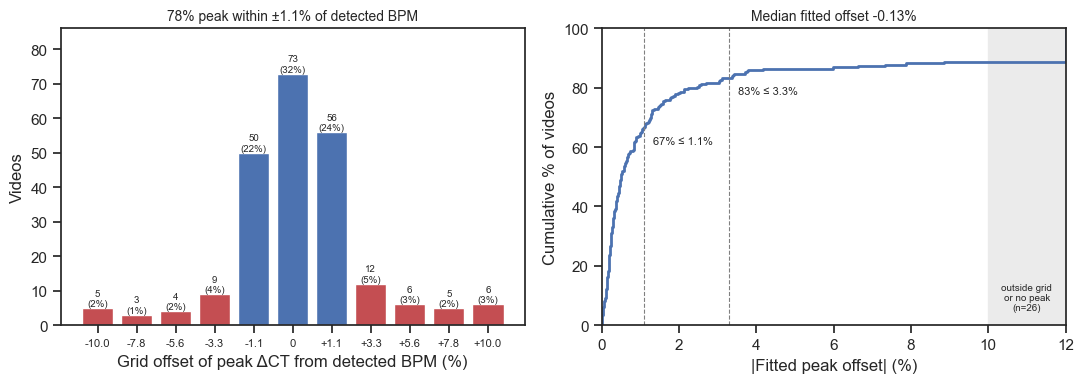

In [37]:
# | label: fig-sensitivity-analysis-hr-histogram-peaks
# | echo: false
# | warning: false

n = len(peaks)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4))

# Left: where each video's ΔCT peaks on the grid
counts = peaks.argmax.value_counts().sort_index()
pos = np.arange(len(counts))
colors = ["C3" if abs(o) >= 3.3 else "C0" for o in counts.index]
bars = ax0.bar(pos, counts.values, width=0.8, color=colors)
ax0.bar_label(
    bars, labels=[f"{c}\n({100 * c / n:.0f}%)" for c in counts.values], fontsize=7
)
ax0.set_xticks(pos, [f"{o:+.1f}" if o else "0" for o in counts.index], fontsize=8)
ax0.set(
    xlabel="Grid offset of peak ΔCT from detected BPM (%)",
    ylabel="Videos",
    ylim=(0, counts.max() * 1.18),
)
within = (peaks.argmax.abs() <= 1.1).mean()
ax0.set_title(f"{within:.0%} peak within ±1.1% of detected BPM", fontsize=10)

# Right: cumulative share of videos by |fitted vertex offset|
v = peaks.vertex.abs().fillna(np.inf).sort_values()  # non-concave -> inf
ecdf = np.arange(1, n + 1) / n
ax1.step(v.clip(upper=12), 100 * ecdf, where="post", color="C0", lw=2)
for t in [1.1, 3.3]:
    p = 100 * (v <= t).mean()
    ax1.axvline(t, color="0.5", ls="--", lw=0.8)
    ax1.annotate(
        f"{p:.0f}% ≤ {t}%",
        (t, p),
        xytext=(6, -12),
        textcoords="offset points",
        fontsize=8,
    )
ax1.axvspan(10, 12, color="0.92", zorder=-1)
ax1.text(
    11,
    5,
    f"outside grid\nor no peak\n(n={int((v > 10).sum())})",
    ha="center",
    fontsize=7,
)
ax1.set(
    xlim=(0, 12),
    ylim=(0, 100),
    xlabel="|Fitted peak offset| (%)",
    ylabel="Cumulative % of videos",
)
ax1.set_title(f"Median fitted offset {peaks.vertex.median():+.2f}%", fontsize=10)
fig.tight_layout()


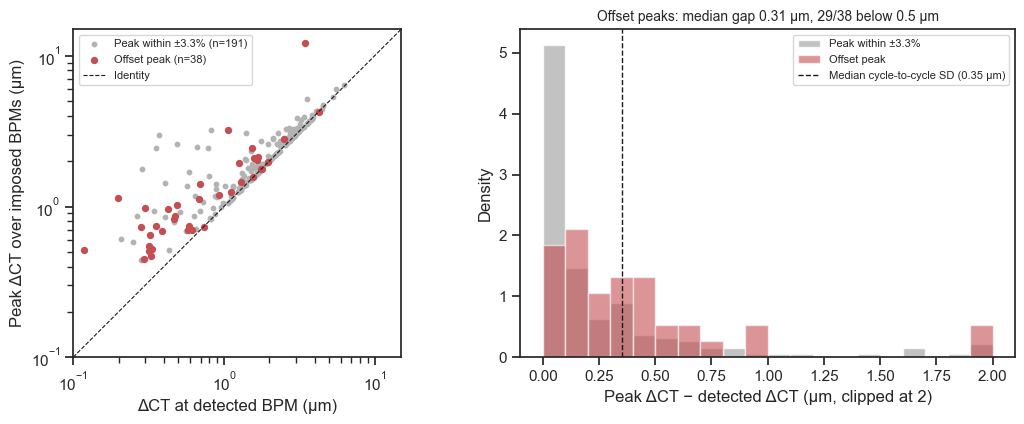

In [ ]:
# | label: fig-sensitivity-analysis-hr-importance-errors
# | echo: false
# | warning: false


raw = sens.pivot_table(index="Video", columns="cat", values="deltaCT_um")
cmp = pd.DataFrame(
    {
        "peak_um": sens[sens.cat != "id_demod"].groupby("Video").deltaCT_um.max(),
        "detected_um": raw.linear_phase,
        "demod_um": raw.id_demod,
        "vertex": peaks.vertex,
    }
)
cmp["off_peak"] = cmp.vertex.abs().gt(3.3) | cmp.vertex.isna()
cmp["diff_um"] = cmp.peak_um - cmp.detected_um
cmp["rel_loss"] = 1 - cmp.detected_um / cmp.peak_um
# Cycle-to-cycle repeatability at the detected BPM (noise floor)
cmp["cycle_sd_um"] = pd.Series(
    {
        video: np.std([d.deltaCT_um for d in cycles["ls_linear.mp4"]], ddof=1)
        for video, cycles in results.items()
    }
)
noise = cmp.cycle_sd_um.median()
on, off = cmp[~cmp.off_peak], cmp[cmp.off_peak]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.4))

# Left: peak vs detected ΔCT
ax0.scatter(
    on.detected_um,
    on.peak_um,
    s=10,
    color="0.7",
    label=f"Peak within ±3.3% (n={len(on)})",
)
ax0.scatter(
    off.detected_um, off.peak_um, s=18, color="C3", label=f"Offset peak (n={len(off)})"
)
lim = (0.1, 15)
ax0.plot(lim, lim, "k--", lw=0.8, label="Identity")
ax0.set(
    xscale="log",
    yscale="log",
    xlim=lim,
    ylim=lim,
    aspect="equal",
    xlabel="ΔCT at detected BPM (µm)",
    ylabel="Peak ΔCT over imposed BPMs (µm)",
)
ax0.legend(fontsize=8, loc="upper left")

# Right: absolute gap vs cycle-to-cycle noise
bins = np.arange(0, 2.01, 0.1)
ax1.hist(
    on.diff_um.clip(upper=2),
    bins=bins,
    color="0.7",
    alpha=0.8,
    density=True,
    label="Peak within ±3.3%",
)
ax1.hist(
    off.diff_um.clip(upper=2),
    bins=bins,
    color="C3",
    alpha=0.6,
    density=True,
    label="Offset peak",
)
ax1.axvline(
    noise, color="k", ls="--", lw=1, label=f"Median cycle-to-cycle SD ({noise:.2f} µm)"
)
ax1.set(xlabel="Peak ΔCT − detected ΔCT (µm, clipped at 2)", ylabel="Density")
ax1.set_title(
    f"Offset peaks: median gap {off.diff_um.median():.2f} µm, "
    f"{(off.diff_um < 0.5).sum()}/{len(off)} below 0.5 µm",
    fontsize=10,
)
ax1.legend(fontsize=8)
fig.tight_layout()
